In [125]:
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.preprocessing import OneHotEncoder , StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report , accuracy_score
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [126]:
#read csv
df = pd.read_csv("churn_cleaned.csv")

In [127]:
df = df.drop("customerid", axis=1)
#Define X and y
x = df.drop("churn", axis=1)
y = df["churn"]

In [128]:
#Split Data fro training 80% and for testing 20%
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [129]:
#Separate Column Types
cat_cols= x_train.select_dtypes(include = "object").columns
num_cols = x_train.select_dtypes(exclude = "object").columns

In [130]:
#Build Preprocessing Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("num" ,StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown = "ignore"), cat_cols) #If you don’t ignore unknown categories, your model will crash in test data.
    ]
)

In [131]:
#Add Model into Pipeline
model_pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor), #This connects your earlier ColumnTransformer.
    ("model", LogisticRegression(max_iter = 1000, class_weight = "balanced")) #Dataset is imbalanced. If you don’t use class_weight: Model may just predict: "Everyone stays and get 74% accuracy. Looks good. But useless.
])

In [132]:
model_pipeline.fit(x_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['seniorcitizen', 'tenure', 'monthlycharges', 'totalcharges'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['gender', 'partner', 'dependents', 'phoneservice', 'multiplelines',
       'internetservice', 'onlinesecurity', 'onlinebackup', 'deviceprotection',
       'techsupport', 'streamingtv', 'streamingmovies', 'contract',
       'paperlessbilling', 'paymentmethod'],
      dtype='object'))])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [133]:
y_pred = model_pipeline.predict(x_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:", classification_report(y_test, y_pred))

Accuracy: 0.7381121362668559
Classification Report:               precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



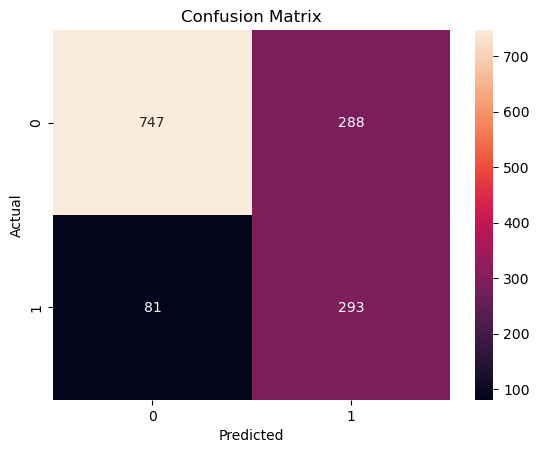

In [134]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
# Plot
plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [135]:
# Get feature names after encoding
ohe = model_pipeline.named_steps["preprocessing"].named_transformers_["cat"] #This line goes inside the pipeline and grabs the OneHotEncoder object.
encoded_cat_cols = ohe.get_feature_names_out(cat_cols) #This extracts the actual new column names created after encoding.

In [136]:
all_features = list(num_cols) + list(encoded_cat_cols)

In [137]:
# Get coefficients
coefficients = model_pipeline.named_steps["model"].coef_[0] #This extracts the weights from Logistic Regression.

In [138]:
feature_importance = pd.DataFrame({
    "Feature": all_features,
    "Coefficient": coefficients
})

In [139]:
feature_importance = feature_importance.sort_values(by="Coefficient", ascending=False)

In [140]:
print(feature_importance.head(10))

                           Feature  Coefficient
16     internetservice_Fiber optic     0.707981
36         contract_Month-to-month     0.657713
3                     totalcharges     0.489698
35             streamingmovies_Yes     0.275392
32                 streamingtv_Yes     0.262166
43  paymentmethod_Electronic check     0.240275
18               onlinesecurity_No     0.199030
27                  techsupport_No     0.165519
14               multiplelines_Yes     0.132843
26            deviceprotection_Yes     0.074190
